# GWAS + Random Forest Pipeline
## Gallstone Disease SNP Analysis

**Workflow:**
1. Load professor's top-SNP list (`summary_results_sorted_by_p.csv`)
2. Load per-gene `.raw` files — only the top-SNP columns
3. Load phenotype from `Merged file with metabolites.xlsx`
4. Merge on IID
5. EDA plots
6. Single-SNP association statistics
7. Random Forest classification
8. Results summary

Packages ready
 Cases: 172 | Controls: 1032
 SNPs: 479
  CDHR3_region.raw: 36 SNPs loaded
  CLDN7_region.raw: 41 SNPs loaded
  CPZ_region.raw: 51 SNPs loaded
  ERICH1_region.raw: 42 SNPs loaded
  EXOC4_region.raw: 39 SNPs loaded
  GALNTL6_region.raw: 44 SNPs loaded
  GPC6_region.raw: 33 SNPs loaded
  GPRIN3_region.raw: 13 SNPs loaded
  HLA-G_region.raw: 19 SNPs loaded
  HMGB1P5_region.raw: 16 SNPs loaded
  LINC01122_region.raw: 10 SNPs loaded
  LRP8_region.raw: 13 SNPs loaded
  LUZP2_region.raw: 16 SNPs loaded
  MATN2_region.raw: 11 SNPs loaded
  OSBPL10_region.raw: 18 SNPs loaded
  PALM2AKAP2_region.raw: 8 SNPs loaded
  PTPRN2_region.raw: 14 SNPs loaded
  RNFT2_region.raw: 19 SNPs loaded
  RPL31P35_region.raw: 10 SNPs loaded
  TJP1_region.raw: 9 SNPs loaded
  UGGT1_region.raw: 17 SNPs loaded
Genotype: (1204, 480)
 Phenotype: 1197 | Cases: 170 | Controls: 1027
 Merged: (1197, 487) | Features: 483
SMOTE done | Train Cases: 821 Controls: 821

Training: RF — SNPs only ...
 CV AUC: 0.5219 

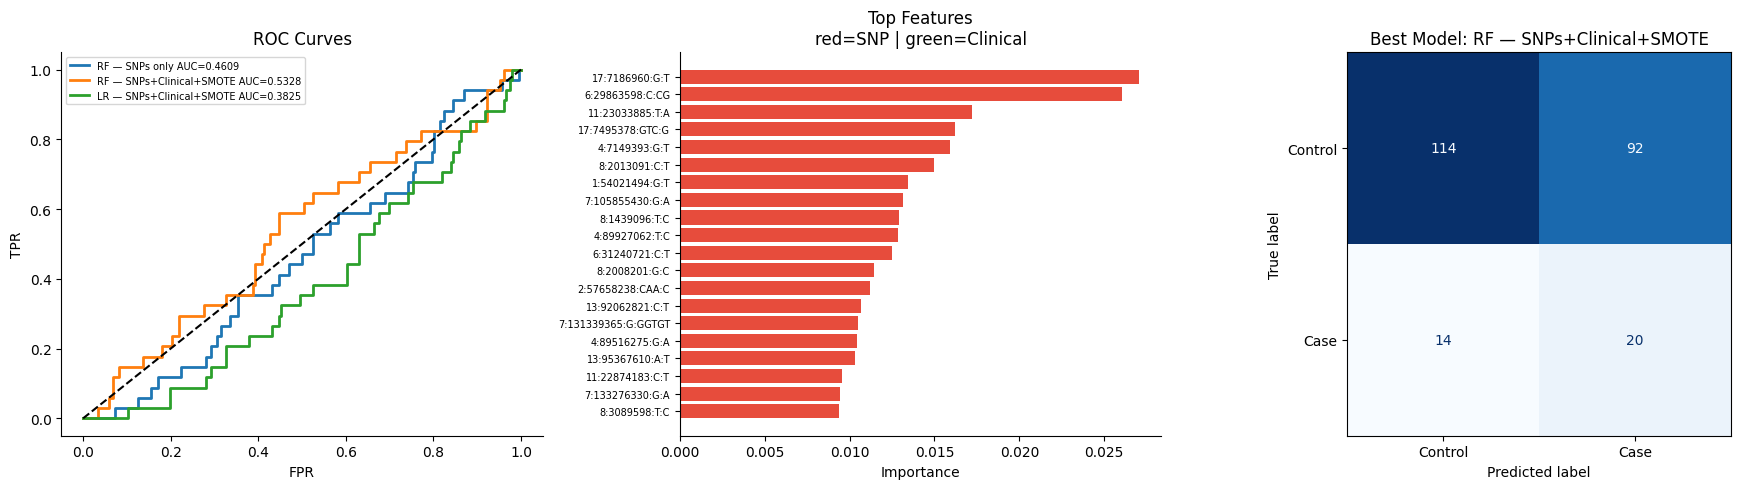


   COMPLETE


,Model,CV_AUC,CV_AUC_std,Test_AUC
0,RF — SNPs only,0.5219,0.0378,0.4609
1,RF — SNPs+Clinical+SMOTE,0.9738,0.0065,0.5328
2,LR — SNPs+Clinical+SMOTE,0.9113,0.0101,0.3825


In [1]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print('Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
warnings.filterwarnings('ignore')
%matplotlib inline

# ── CONFIG ────────────────────────────────────────────────────────────────────
BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output'
OUT.mkdir(exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'Merged file with metabolites.xlsx'
CASES_TXT  = BASE / 'ID_gsd_172cases.txt'
CTRLS_TXT  = BASE / 'ID_gsd_1032controls.txt'

# ── STEP 1: Matched IDs ───────────────────────────────────────────────────────
cases_ids = pd.read_csv(CASES_TXT, sep=' ', dtype=str)
ctrl_ids  = pd.read_csv(CTRLS_TXT, sep=' ', dtype=str)
case_iids = cases_ids['IID'].str.strip().tolist()
ctrl_iids = ctrl_ids['IID'].str.strip().tolist()
all_selected_iids = set(case_iids + ctrl_iids)
print(f' Cases: {len(case_iids)} | Controls: {len(ctrl_iids)}')

# ── STEP 2: SNPs ──────────────────────────────────────────────────────────────
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f' SNPs: {len(snp_df)}')

# ── STEP 3: Genotype ──────────────────────────────────────────────────────────
def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map:
        return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs loaded')
    return df

raw_files = sorted(BASE.glob('*_region.raw'))
gene_map  = {f.stem.replace('_region','').strip('_').upper(): f for f in raw_files}
gene_snps = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()

frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None:
        print(f'WARNING: no .raw for {gene}')
        continue
    chunk = load_raw(path, snps)
    if not chunk.empty:
        frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno          = geno.loc[:, ~geno.columns.duplicated()]
geno_filtered = geno[geno['IID'].isin(all_selected_iids)].copy()
print(f'Genotype: {geno_filtered.shape}')

# ── STEP 4: Phenotype + clinical ──────────────────────────────────────────────
pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns  = pheno.columns.str.replace('\n',' ').str.strip()
pheno          = pheno.rename(columns={'IID2':'IID_match'})

clinical_search = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
available_clin  = []
for col in clinical_search:
    match = [c for c in pheno.columns if col.lower() in c.lower()]
    if match:
        available_clin.append(match[0])

if 'Gender' in available_clin:
    pheno['Gender'] = LabelEncoder().fit_transform(pheno['Gender'].fillna('Unknown'))
for col in available_clin:
    pheno[col] = pd.to_numeric(pheno[col], errors='coerce')

pheno = pheno[pheno['IID_match'].isin(all_selected_iids)].copy()
pheno['gall']      = pheno['gall'].str.lower()
pheno              = pheno[pheno['gall'].isin({'yes','no'})].copy()
pheno['label']     = (pheno['gall']=='yes').astype(int)
pheno['IID_match'] = pheno['IID_match'].astype(str)
print(f' Phenotype: {len(pheno)} | Cases: {pheno["label"].sum()} | Controls: {(pheno["label"]==0).sum()}')

# ── STEP 5: Merge ─────────────────────────────────────────────────────────────
merged = pd.merge(geno_filtered,
                  pheno[['IID_match','gall','label']+available_clin],
                  left_on='IID', right_on='IID_match', how='inner')
snp_cols     = [c for c in merged.columns if c in set(geno.columns)-{'IID'}]
all_features = snp_cols + available_clin
print(f' Merged: {merged.shape} | Features: {len(all_features)}')

# ── STEP 6: Features + SMOTE ──────────────────────────────────────────────────
X = SimpleImputer(strategy='median').fit_transform(
    merged[all_features].apply(pd.to_numeric, errors='coerce'))
y = merged['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_tr, y_tr)
print(f'SMOTE done | Train Cases: {y_tr_sm.sum()} Controls: {(y_tr_sm==0).sum()}')

# ── STEP 7: Models — FAST settings ───────────────────────────────────────────
# n_estimators=100 and cv=3 to run fast
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()

models = {
    'RF — SNPs only' : (
        RandomForestClassifier(
            n_estimators=100, max_depth=6,   # ← reduced for speed
            class_weight={0:1,1:neg/pos},
            random_state=42, n_jobs=-1),
        X_tr, y_tr),

    'RF — SNPs+Clinical+SMOTE' : (
        RandomForestClassifier(
            n_estimators=100, max_depth=6,   # ← reduced for speed
            random_state=42, n_jobs=-1),
        X_tr_sm, y_tr_sm),

    'LR — SNPs+Clinical+SMOTE' : (
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                max_iter=1000, C=0.01,
                random_state=42, solver='saga'))]),
        X_tr_sm, y_tr_sm),
}

cv           = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 fold for speed
results_list = []
trained      = {}

for name, (model, Xtr, ytr) in models.items():
    print(f'\nTraining: {name} ...')
    cv_auc = cross_val_score(model, Xtr, ytr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(Xtr, ytr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec, rec, thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)
    print(f' CV AUC: {cv_auc.mean():.4f} | Test AUC: {auc:.4f} | Acc: {acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))

    trained[name] = (model, auc, y_prob)
    results_list.append({
        'Model'     : name,
        'CV_AUC'    : round(cv_auc.mean(),4),
        'CV_AUC_std': round(cv_auc.std(),4),
        'Test_AUC'  : round(auc,4),
    })

# ── STEP 8: Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for name, (model, auc, y_prob) in trained.items():
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} AUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=7)
axes[0].spines[['top','right']].set_visible(False)

# Feature importance — RF SMOTE
rf_smote = trained['RF — SNPs+Clinical+SMOTE'][0]
imp      = rf_smote.feature_importances_
top_n    = min(20, len(all_features))
idx      = np.argsort(imp)[::-1][:top_n]
colors_b = ['#e74c3c' if all_features[i] in snp_cols else '#2ecc71' for i in idx]
axes[1].barh(range(top_n), imp[idx][::-1], color=colors_b[::-1])
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([all_features[i] for i in idx][::-1], fontsize=7)
axes[1].set_xlabel('Importance')
axes[1].set_title('Top Features\nred=SNP | green=Clinical')
axes[1].spines[['top','right']].set_visible(False)

# Confusion matrix — best model
best_name = max(trained, key=lambda x: trained[x][1])
best_prob = trained[best_name][2]
prec,rec,thr = precision_recall_curve(y_te, best_prob)
f1s = 2*prec*rec/(prec+rec+1e-8)
y_pred_best = (best_prob >= thr[np.argmax(f1s)]).astype(int)
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred_best),
    display_labels=['Control','Case']
).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Best Model: {best_name}')

plt.tight_layout()
plt.savefig(OUT/'final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 9: Save ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'final_results.csv', index=False)
print('\n'+'='*55)
print('   COMPLETE')
print('='*55)
display(results_df)

Training Model 1 — Weighted RF (no SMOTE)...
 CV AUC: 0.5045 | Test AUC: 0.4288 | Gap: 0.0758

Training Model 2 — RF with SMOTE...
 CV AUC: 0.9802 | Test AUC: 0.4766 | Gap: 0.5036


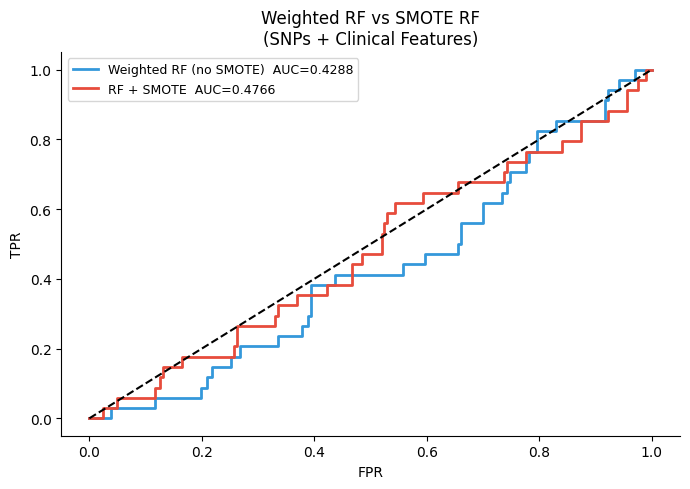


── FINAL SUMMARY ──────────────────────────
Weighted RF  — CV: 0.5045  Test: 0.4288  Gap: 0.0758
RF + SMOTE   — CV: 0.9802  Test: 0.4766  Gap: 0.5036
Lower gap = less overfitting = more reliable


In [2]:
# Final honest comparison — with and without SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()

# Model 1 — weighted RF no SMOTE
rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    class_weight={0:1, 1:neg/pos},
    random_state=42, n_jobs=-1)

# Model 2 — RF with SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    random_state=42, n_jobs=-1)

print('Training Model 1 — Weighted RF (no SMOTE)...')
cv1 = cross_val_score(rf_weighted, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_weighted.fit(X_tr, y_tr)
prob1 = rf_weighted.predict_proba(X_te)[:,1]
auc1  = roc_auc_score(y_te, prob1)
print(f' CV AUC: {cv1.mean():.4f} | Test AUC: {auc1:.4f} | Gap: {cv1.mean()-auc1:.4f}')

print('\nTraining Model 2 — RF with SMOTE...')
cv2 = cross_val_score(rf_smote, X_tr_sm, y_tr_sm, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_smote.fit(X_tr_sm, y_tr_sm)
prob2 = rf_smote.predict_proba(X_te)[:,1]
auc2  = roc_auc_score(y_te, prob2)
print(f' CV AUC: {cv2.mean():.4f} | Test AUC: {auc2:.4f} | Gap: {cv2.mean()-auc2:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7,5))
for prob, auc, name, color in [
    (prob1, auc1, 'Weighted RF (no SMOTE)', '#3498db'),
    (prob2, auc2, 'RF + SMOTE',             '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Weighted RF vs SMOTE RF\n(SNPs + Clinical Features)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT/'weighted_vs_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── FINAL SUMMARY ──────────────────────────')
print(f'Weighted RF  — CV: {cv1.mean():.4f}  Test: {auc1:.4f}  Gap: {cv1.mean()-auc1:.4f}')
print(f'RF + SMOTE   — CV: {cv2.mean():.4f}  Test: {auc2:.4f}  Gap: {cv2.mean()-auc2:.4f}')
print('Lower gap = less overfitting = more reliable')

Training Model 1 — Weighted RF (no SMOTE)...
 CV AUC: 0.5045 | Test AUC: 0.4288 | Gap: 0.0758

Training Model 2 — RF with SMOTE...
 CV AUC: 0.9802 | Test AUC: 0.4766 | Gap: 0.5036


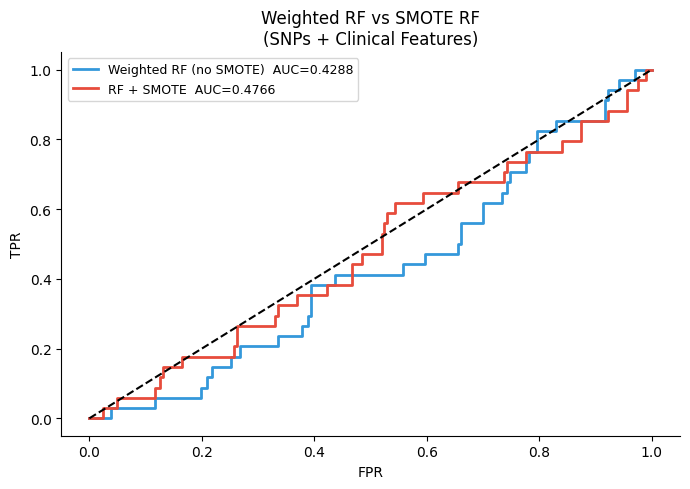


── FINAL SUMMARY ──────────────────────────
Weighted RF  — CV: 0.5045  Test: 0.4288  Gap: 0.0758
RF + SMOTE   — CV: 0.9802  Test: 0.4766  Gap: 0.5036
Lower gap = less overfitting = more reliable


In [ ]:
# Final honest comparison — with and without SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()

# Model 1 — weighted RF no SMOTE
rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    class_weight={0:1, 1:neg/pos},
    random_state=42, n_jobs=-1)

# Model 2 — RF with SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    random_state=42, n_jobs=-1)

print('Training Model 1 — Weighted RF (no SMOTE)...')
cv1 = cross_val_score(rf_weighted, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_weighted.fit(X_tr, y_tr)
prob1 = rf_weighted.predict_proba(X_te)[:,1]
auc1  = roc_auc_score(y_te, prob1)
print(f' CV AUC: {cv1.mean():.4f} | Test AUC: {auc1:.4f} | Gap: {cv1.mean()-auc1:.4f}')

print('\nTraining Model 2 — RF with SMOTE...')
cv2 = cross_val_score(rf_smote, X_tr_sm, y_tr_sm, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_smote.fit(X_tr_sm, y_tr_sm)
prob2 = rf_smote.predict_proba(X_te)[:,1]
auc2  = roc_auc_score(y_te, prob2)
print(f' CV AUC: {cv2.mean():.4f} | Test AUC: {auc2:.4f} | Gap: {cv2.mean()-auc2:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7,5))
for prob, auc, name, color in [
    (prob1, auc1, 'Weighted RF (no SMOTE)', '#3498db'),
    (prob2, auc2, 'RF + SMOTE',             '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Weighted RF vs SMOTE RF\n(SNPs + Clinical Features)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT/'weighted_vs_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── FINAL SUMMARY ──────────────────────────')
print(f'Weighted RF  — CV: {cv1.mean():.4f}  Test: {auc1:.4f}  Gap: {cv1.mean()-auc1:.4f}')
print(f'RF + SMOTE   — CV: {cv2.mean():.4f}  Test: {auc2:.4f}  Gap: {cv2.mean()-auc2:.4f}')
print('Lower gap = less overfitting = more reliable')